<a href="https://www.kaggle.com/code/sonawanelalitsunil/introvert-vs-extrovert-prediction-ml-97?scriptVersionId=259732866" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e7/sample_submission.csv
/kaggle/input/playground-series-s5e7/train.csv
/kaggle/input/playground-series-s5e7/test.csv


## Title:
Introvert vs Extrovert Prediction

## Description:
This project focuses on building machine learning models to distinguish introverts from extroverts based on behavioral, social, and personality-related features. The dataset includes attributes such as time spent alone, stage fear, social event attendance, frequency of going outside, energy drain after socializing, size of friend circle, and posting frequency.

## The workflow involves:

Data exploration & visualization to understand personality-related trends

Preprocessing & feature engineering for categorical and numerical attributes

Model training & evaluation using multiple algorithms including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, LightGBM, XGBoost, SVM, KNN, and Naive Bayes

Performance metrics such as Balanced Accuracy and Macro F1-score to handle class imbalance

Feature importance analysis to identify which social and behavioral factors most influence personality classification

The goal is to accurately predict whether a person is introverted or extroverted, while also gaining insights into the key traits that differentiate them.

## Import dataset

In [2]:
train = pd.read_csv("/kaggle/input/playground-series-s5e7/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e7/test.csv")
sample_submission = ("/kaggle/input/playground-series-s5e7/sample_submission.csv")

In [3]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"sample_submission: (sample_submission.shape)")

Train shape: (18524, 9)
Test shape: (6175, 8)
sample_submission: (sample_submission.shape)


In [4]:
print("Train head:")
display(train.head())

Train head:


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [5]:
print("Train tail:")
display(train.tail())

Train tail:


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
18519,18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,18520,1.0,NaN,6.0,7.0,No,6.0,5.0,Extrovert
18521,18521,7.0,Yes,1.0,1.0,Yes,1.0,NaN,Introvert
18522,18522,NaN,Yes,1.0,0.0,Yes,5.0,2.0,Introvert
18523,18523,1.0,No,8.0,6.0,No,4.0,7.0,Extrovert


In [6]:
print("Test head:")
display(test.head())

Test head:


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.0,No,7.0,4.0,No,6.0,NaN
1,18525,NaN,Yes,0.0,0.0,Yes,5.0,1.0
2,18526,3.0,No,5.0,6.0,No,15.0,9.0
3,18527,3.0,No,4.0,4.0,No,5.0,6.0
4,18528,9.0,Yes,1.0,2.0,Yes,1.0,1.0


In [7]:
print("Test tail:")
display(test.tail())

Test tail:


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
6170,24694,3.0,No,5.0,5.0,No,9.0,6.0
6171,24695,8.0,Yes,2.0,1.0,Yes,0.0,0.0
6172,24696,2.0,No,4.0,3.0,No,9.0,7.0
6173,24697,3.0,No,4.0,4.0,No,11.0,9.0
6174,24698,NaN,Yes,1.0,1.0,Yes,1.0,0.0


In [8]:
print("Train info():")
print(train.info())

Train info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB
None


In [9]:
print("Test info():")
print(test.info())

Test info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6175 entries, 0 to 6174
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         6175 non-null   int64  
 1   Time_spent_Alone           5750 non-null   float64
 2   Stage_fear                 5577 non-null   object 
 3   Social_event_attendance    5778 non-null   float64
 4   Going_outside              5709 non-null   float64
 5   Drained_after_socializing  5743 non-null   object 
 6   Friends_circle_size        5825 non-null   float64
 7   Post_frequency             5767 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 386.1+ KB
None


In [10]:
print("Missing values (train):")
print(train.isnull().sum())


Missing values (train):
id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64


In [11]:
print("Missing values (test):")
print(test.isnull().sum())


Missing values (test):
id                             0
Time_spent_Alone             425
Stage_fear                   598
Social_event_attendance      397
Going_outside                466
Drained_after_socializing    432
Friends_circle_size          350
Post_frequency               408
dtype: int64


In [12]:
print("Target value counts:")
print(train['Personality'].value_counts(normalize=True))


Target value counts:
Personality
Extrovert    0.739527
Introvert    0.260473
Name: proportion, dtype: float64


In [13]:
target = 'Personality'
features = [col for col in train.columns if col != target]

In [14]:
num_features = train[features].select_dtypes(include=['int64', 'float64']).columns
cat_features = train[features].select_dtypes(include=['object']).columns

In [15]:
print("Numerical features:", list(num_features))
print("Categorical features:", list(cat_features))

Numerical features: ['id', 'Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
Categorical features: ['Stage_fear', 'Drained_after_socializing']


In [16]:
print("Numerical feature summary:")
display(train[num_features].describe().T)

Numerical feature summary:


,count,mean,std,min,25%,50%,75%,max
id,18524.0,9261.500000,5347.562529,0.0,4630.75,9261.5,13892.25,18523.0
Time_spent_Alone,17334.0,3.137764,3.003786,0.0,1.00,2.0,4.00,11.0
Social_event_attendance,17344.0,5.265106,2.753359,0.0,3.00,5.0,8.00,10.0
Going_outside,17058.0,4.044319,2.062580,0.0,3.00,4.0,6.00,7.0
Friends_circle_size,17470.0,7.996737,4.223484,0.0,5.00,8.0,12.00,15.0
Post_frequency,17260.0,4.982097,2.879139,0.0,3.00,5.0,7.00,10.0


In [17]:
print("Categorical feature summary:")
for col in cat_features:
    print(f"{col} -> unique: {train[col].nunique()}, top: {train[col].value_counts().index[0]}")

Categorical feature summary:
Stage_fear -> unique: 2, top: No
Drained_after_socializing -> unique: 2, top: No


In [18]:
train.columns

Index(['id', 'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [19]:
test.columns

Index(['id', 'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency'],
      dtype='object')

## Data visualizations

## Train dataset

In [20]:
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (8, 5)

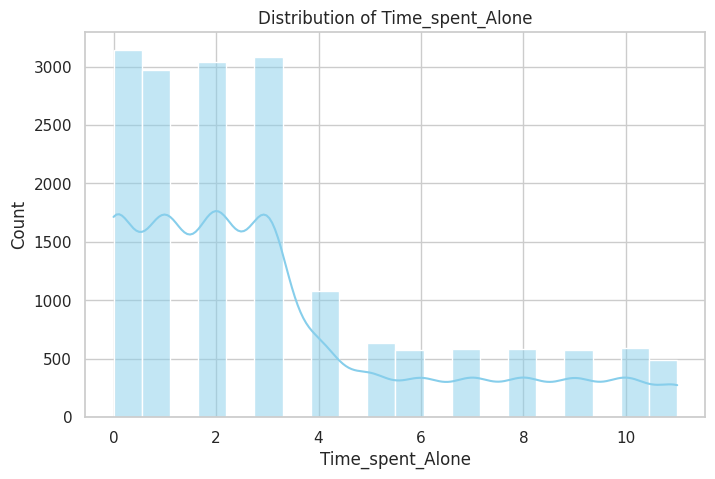

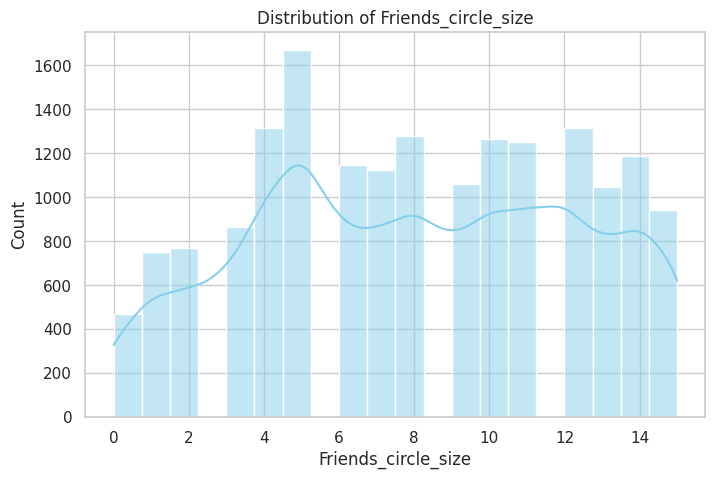

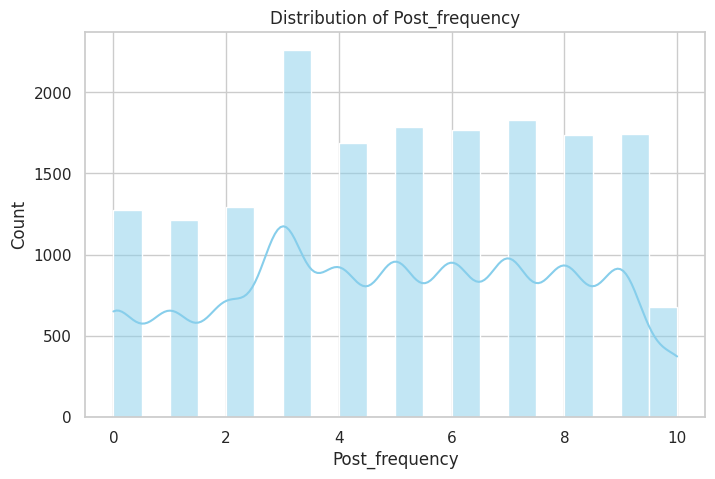

In [21]:
num_cols = ['Time_spent_Alone', 'Friends_circle_size', 'Post_frequency']

for col in num_cols:
    plt.figure()
    sns.histplot(train[col], kde=True, bins=20, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.show()

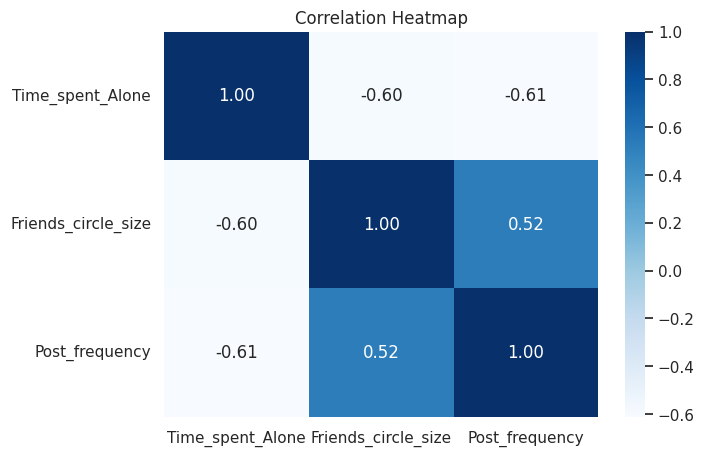

In [22]:
plt.figure(figsize=(7,5))
corr = train[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

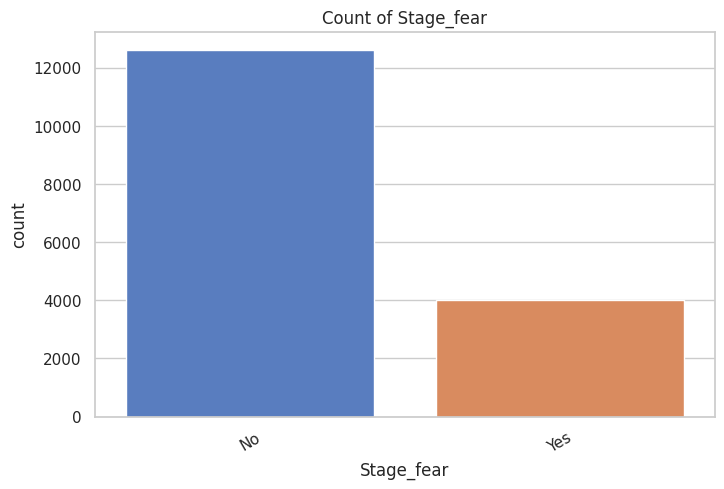

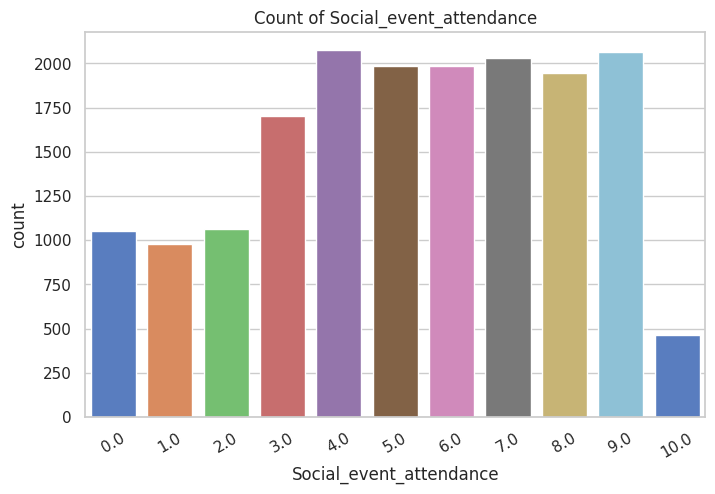

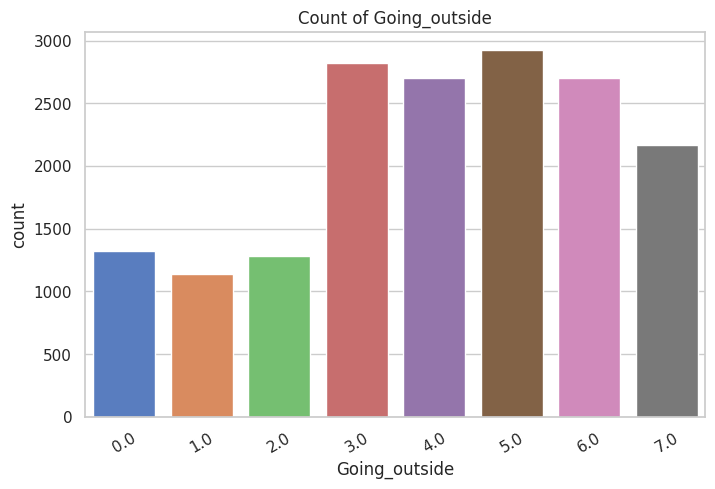

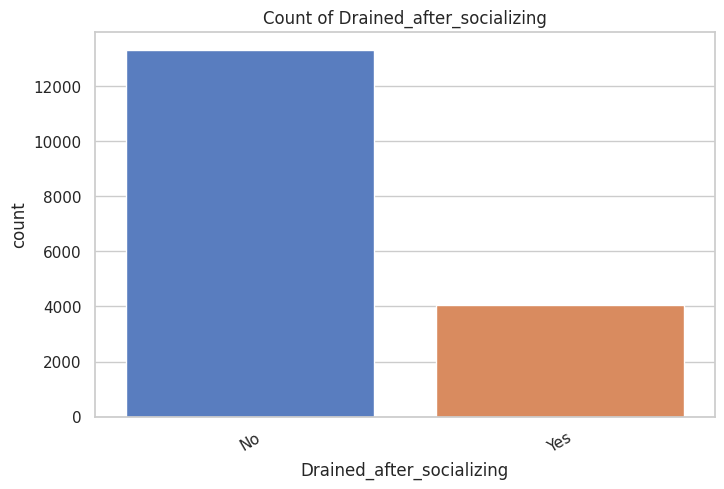

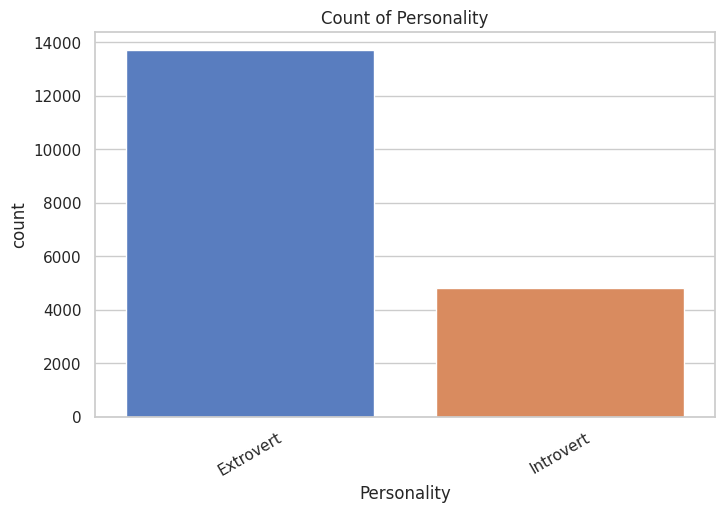

In [23]:
cat_cols = ['Stage_fear', 'Social_event_attendance', 'Going_outside', 
            'Drained_after_socializing', 'Personality']

for col in cat_cols:
    plt.figure()
    sns.countplot(data=train, x=col, palette="muted")
    plt.title(f"Count of {col}")
    plt.xticks(rotation=30)
    plt.show()

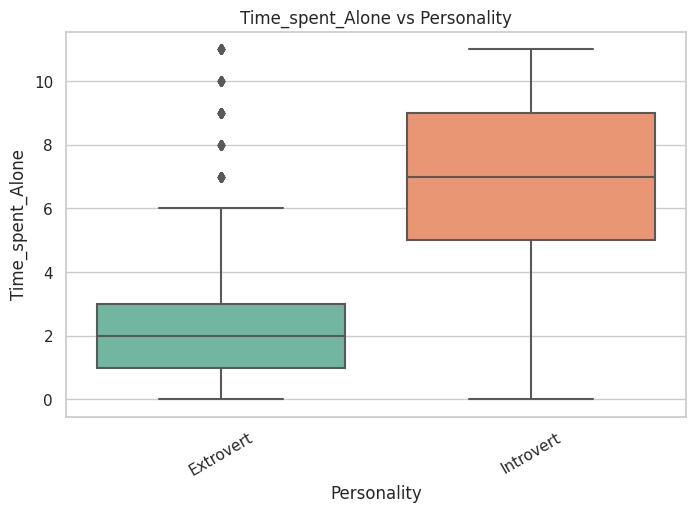

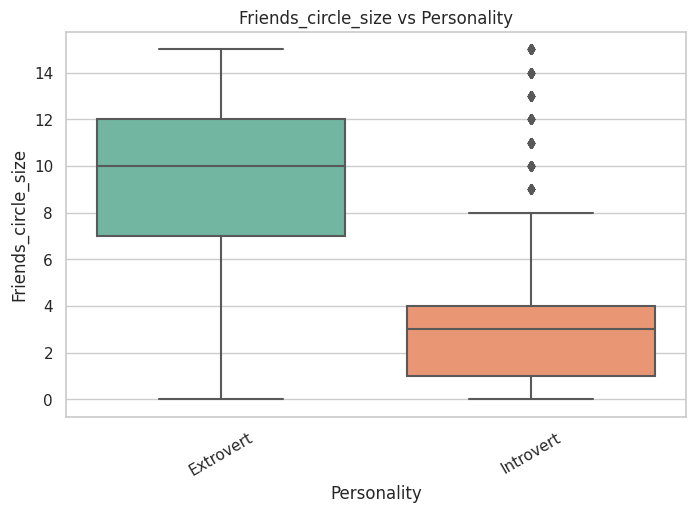

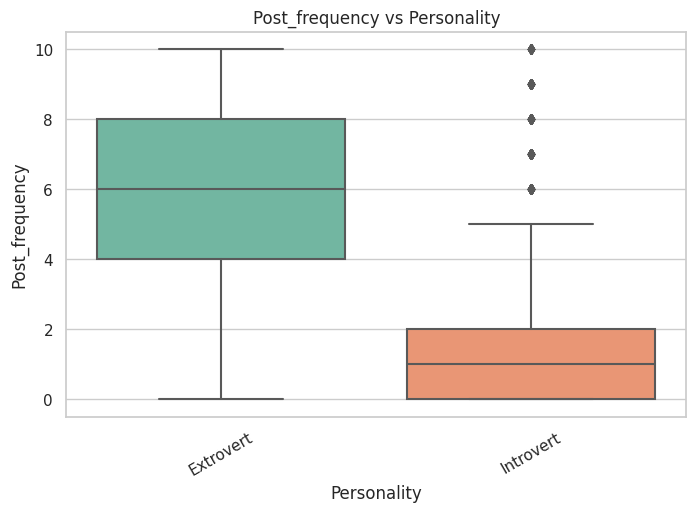

In [24]:
for col in num_cols:
    plt.figure()
    sns.boxplot(data=train, x="Personality", y=col, palette="Set2")
    plt.title(f"{col} vs Personality")
    plt.xticks(rotation=30)
    plt.show()


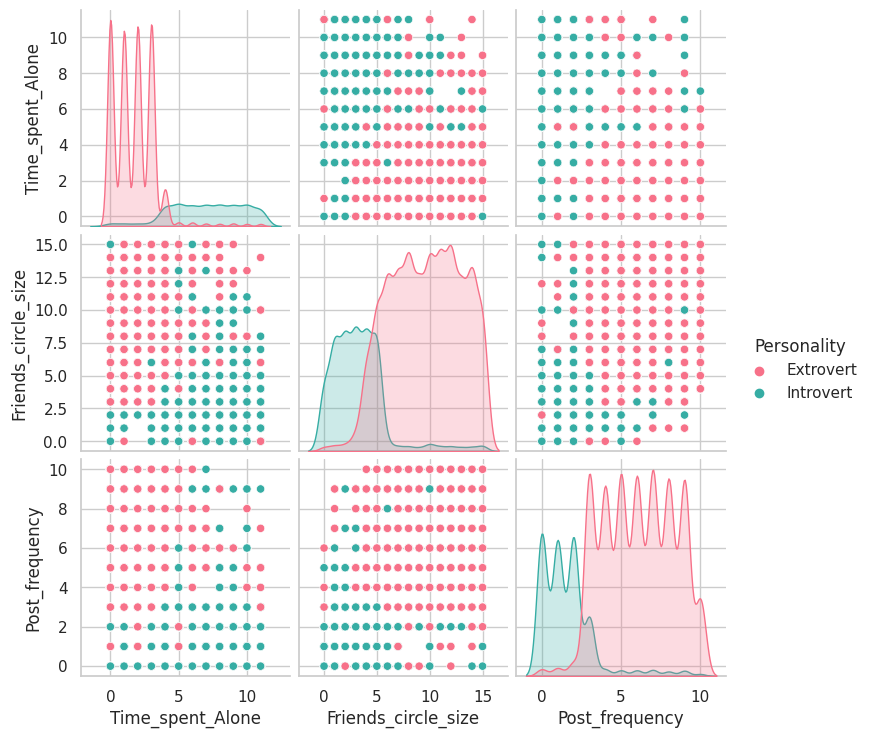

In [25]:
sns.pairplot(train[num_cols + ["Personality"]], hue="Personality", palette="husl")
plt.show()

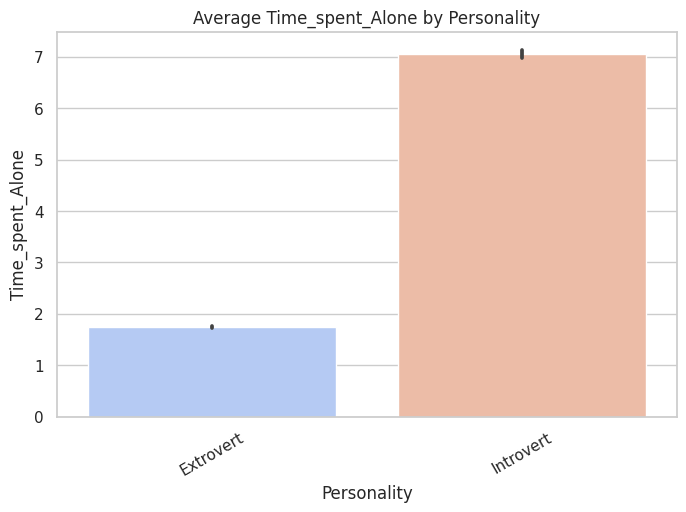

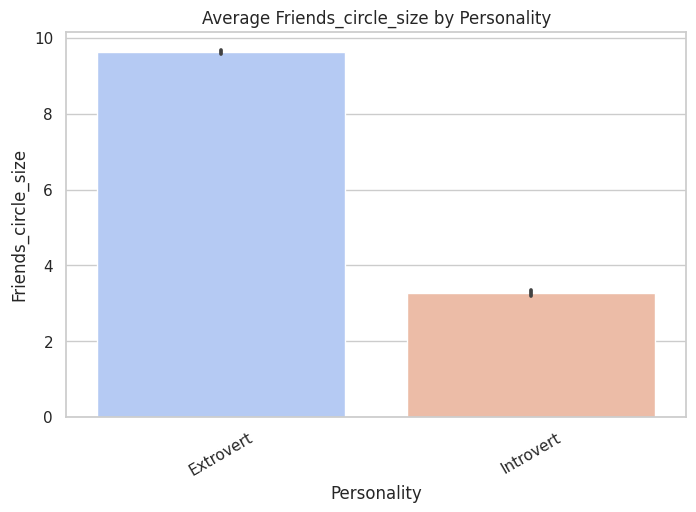

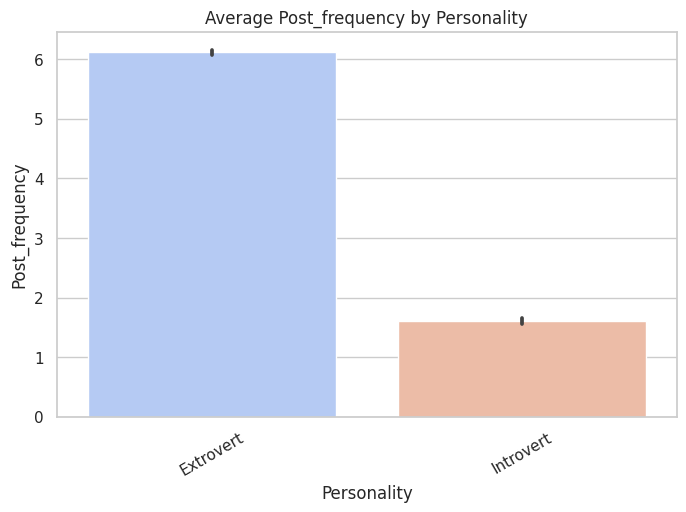

In [26]:
for col in num_cols:
    plt.figure()
    sns.barplot(data=train, x="Personality", y=col, estimator="mean", palette="coolwarm")
    plt.title(f"Average {col} by Personality")
    plt.xticks(rotation=30)
    plt.show()

## Test Dataset

In [27]:
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

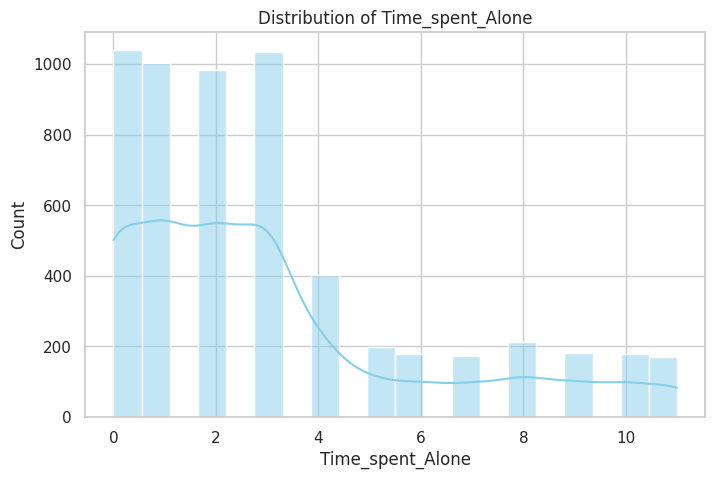

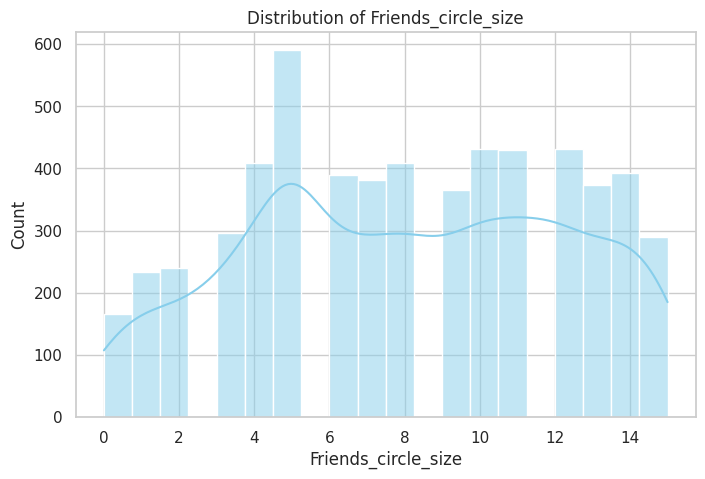

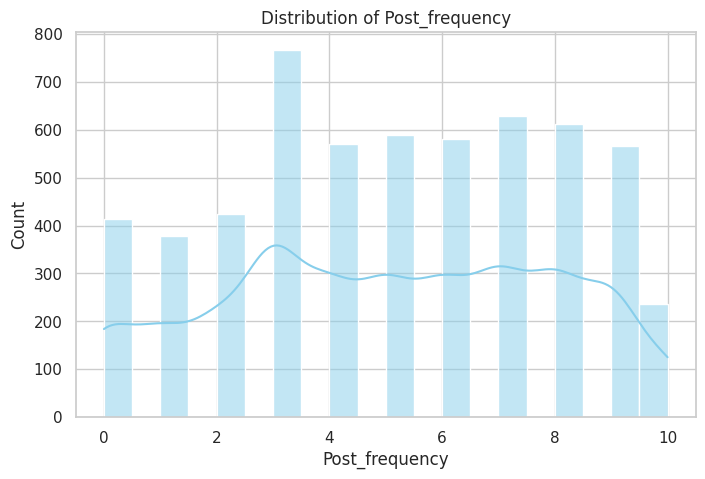

In [28]:
num_cols = ['Time_spent_Alone', 'Friends_circle_size', 'Post_frequency']

for col in num_cols:
    plt.figure()
    sns.histplot(test[col], kde=True, bins=20, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.show()

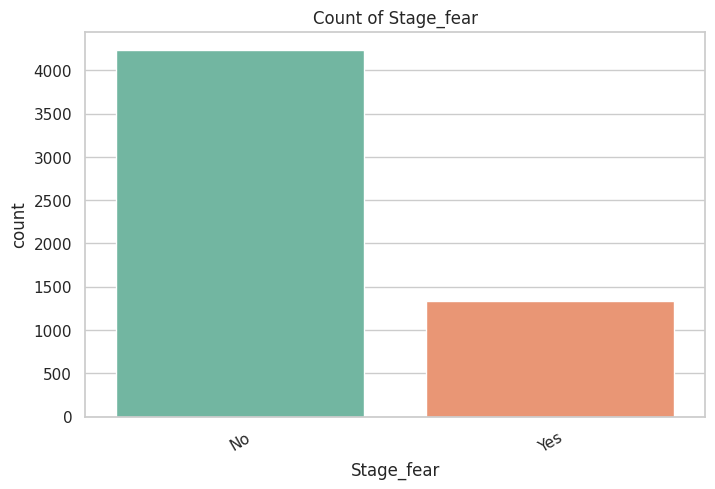

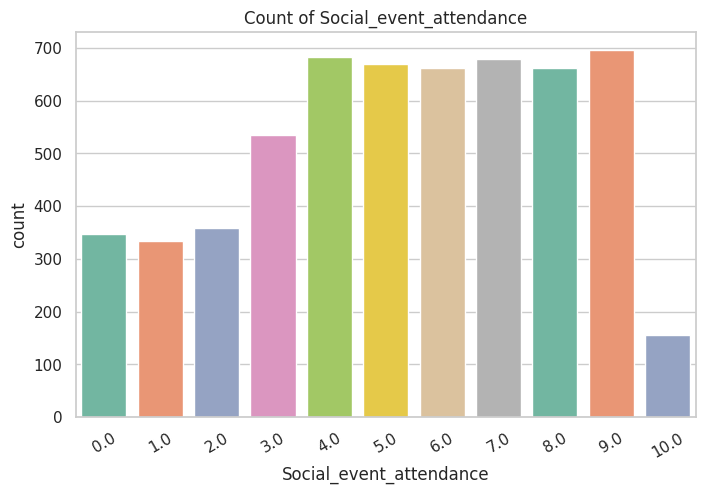

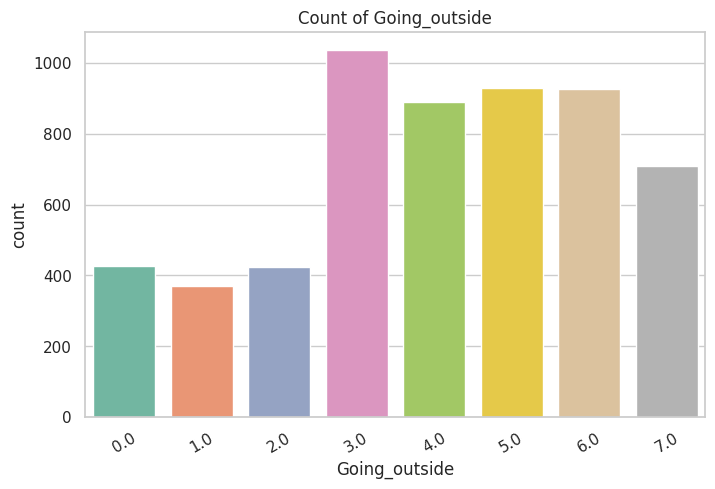

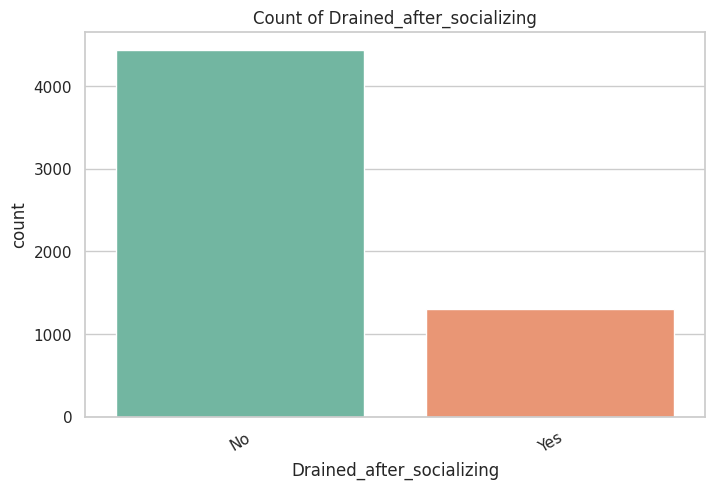

In [29]:
cat_cols = ['Stage_fear', 'Social_event_attendance', 
            'Going_outside', 'Drained_after_socializing']

for col in cat_cols:
    plt.figure()
    sns.countplot(data=test, x=col, palette="Set2")
    plt.title(f"Count of {col}")
    plt.xticks(rotation=30)
    plt.show()


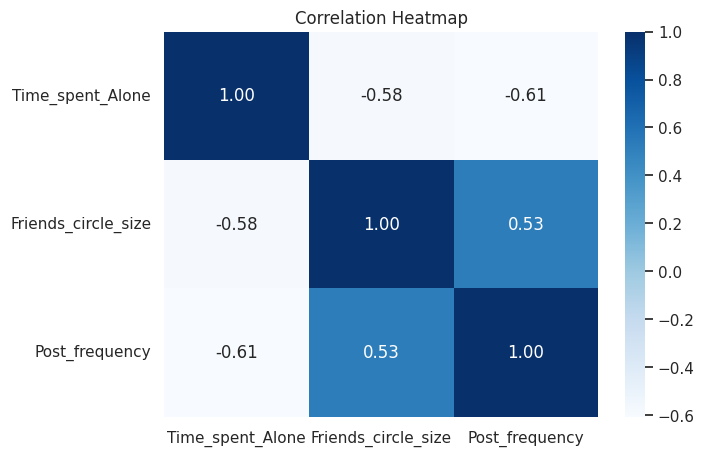

In [30]:
plt.figure(figsize=(7, 5))
corr = test[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

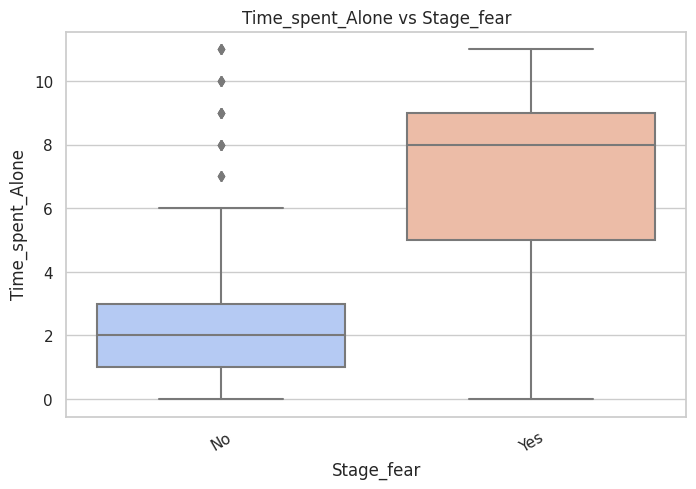

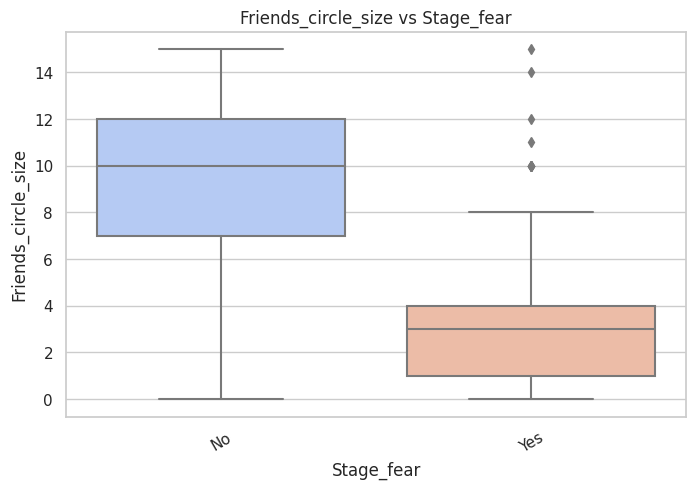

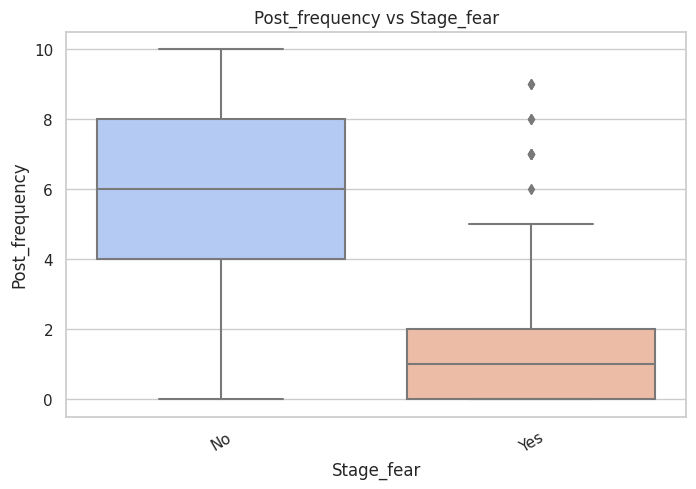

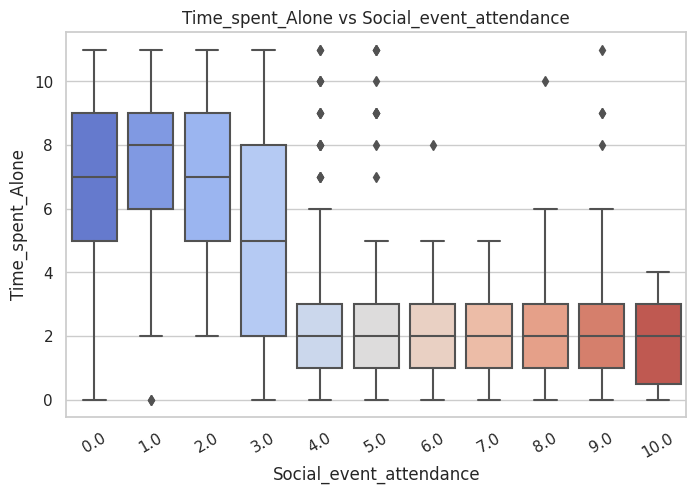

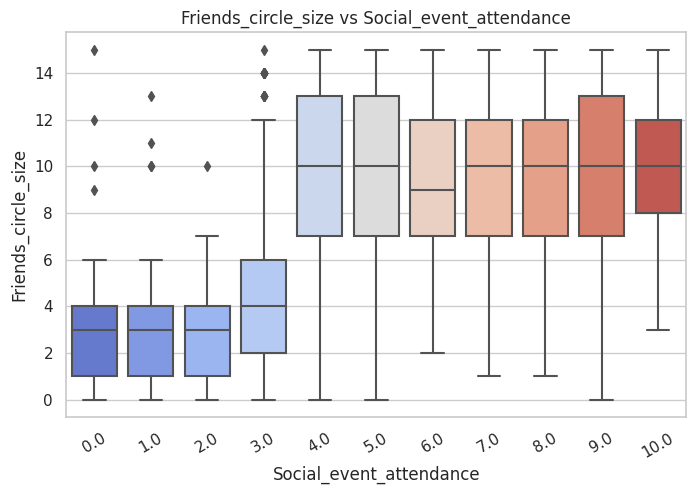

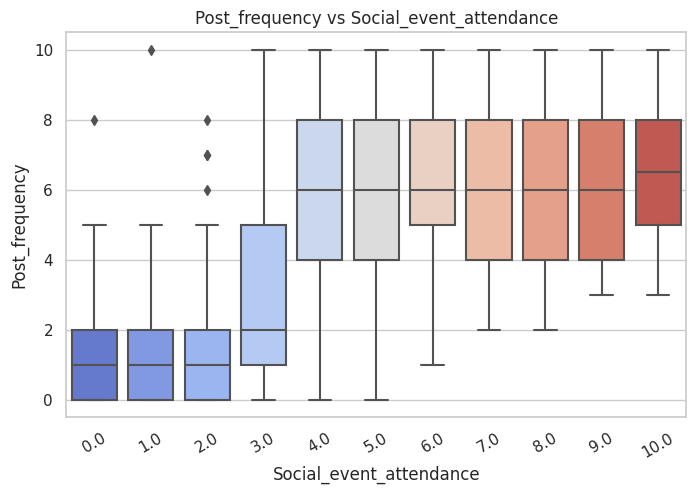

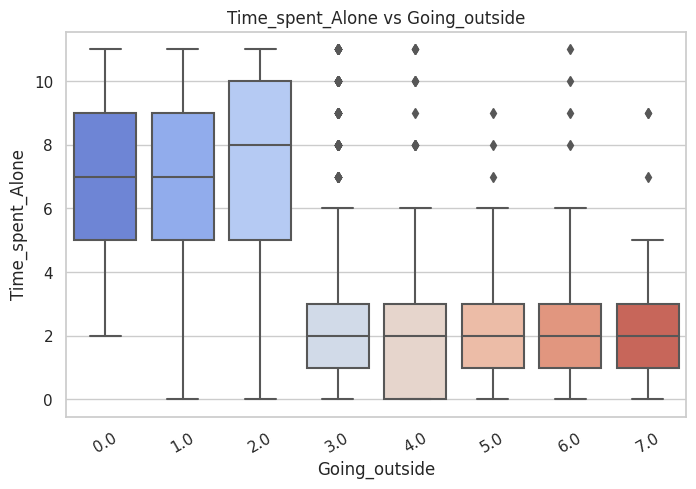

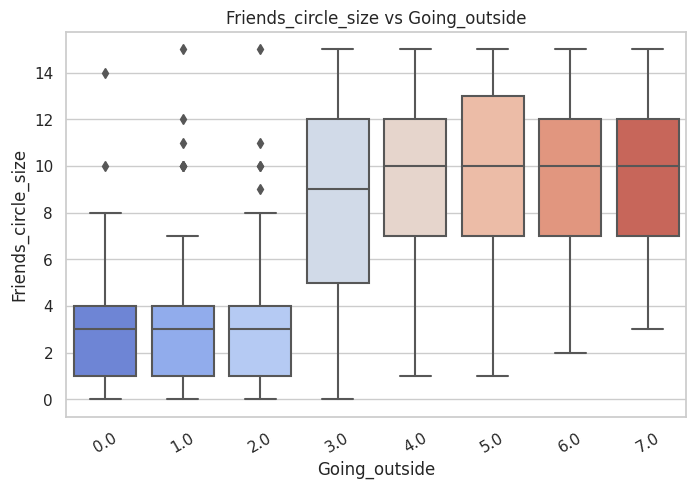

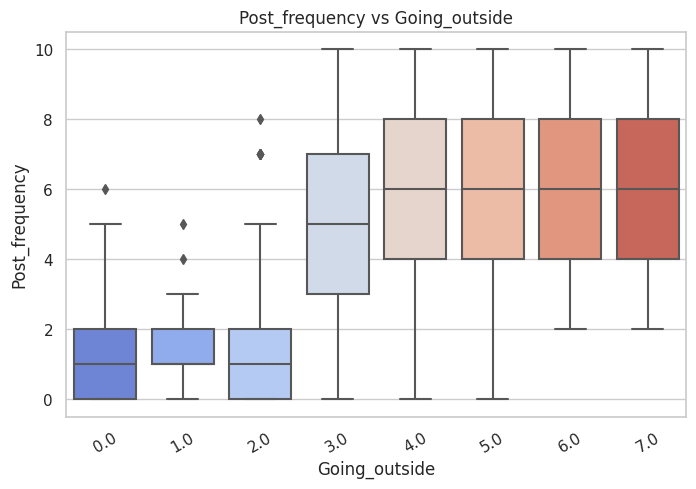

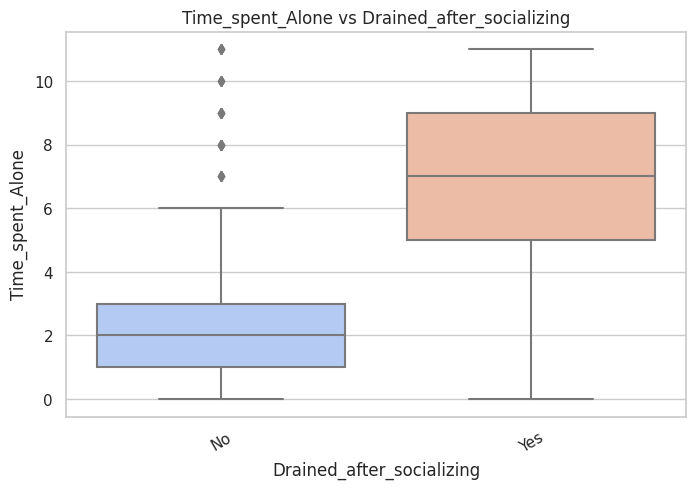

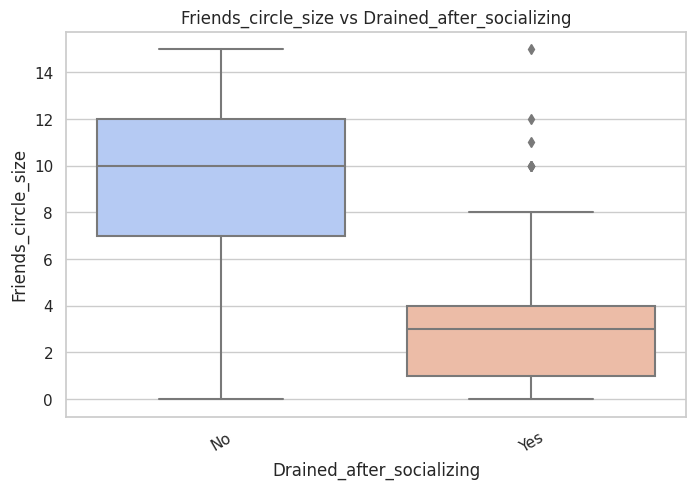

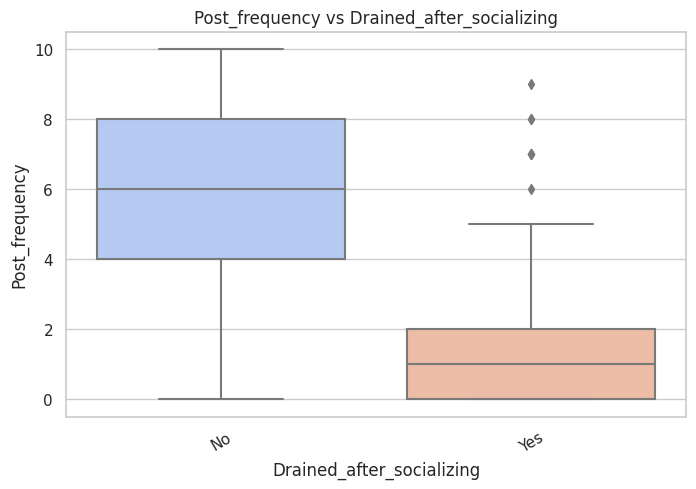

In [31]:
for cat in cat_cols:
    for num in num_cols:
        plt.figure()
        sns.boxplot(data=test, x=cat, y=num, palette="coolwarm")
        plt.title(f"{num} vs {cat}")
        plt.xticks(rotation=30)
        plt.show()

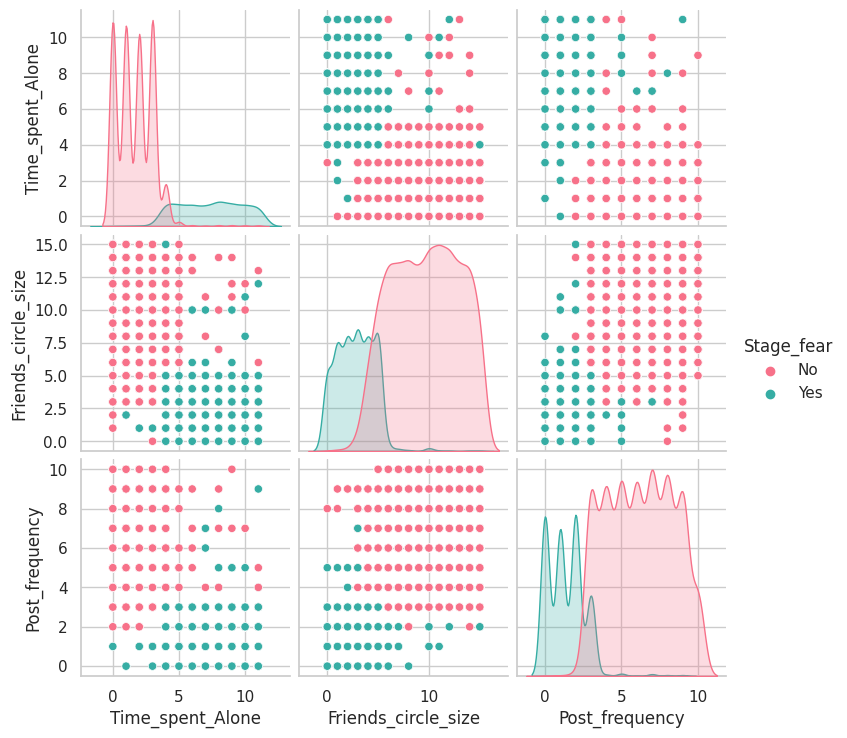

In [32]:
sns.pairplot(test[num_cols + ["Stage_fear"]], hue="Stage_fear", palette="husl")
plt.show()

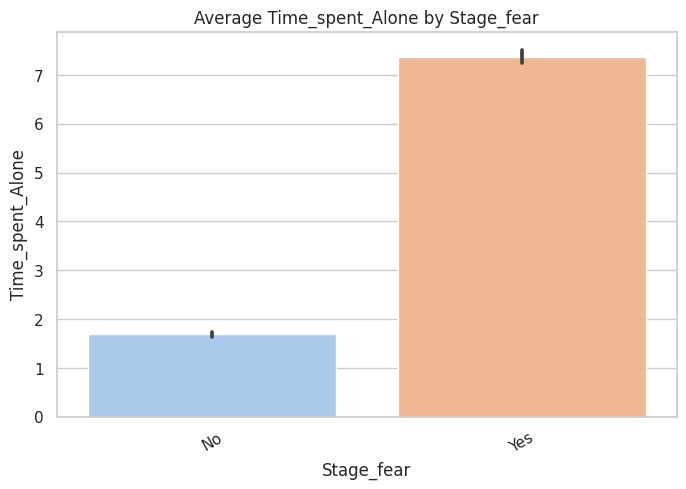

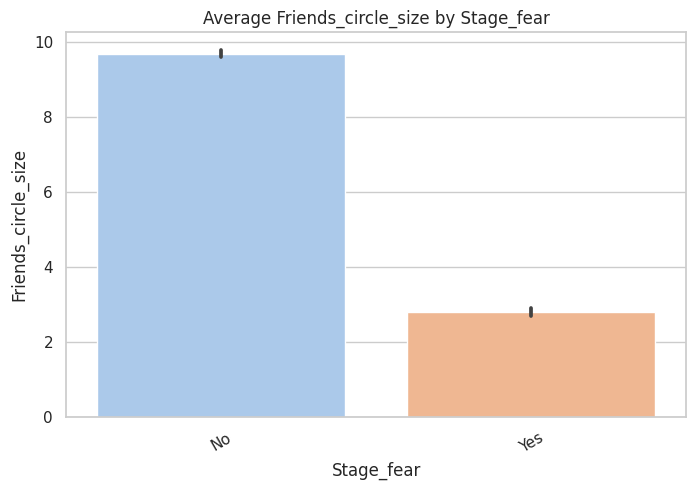

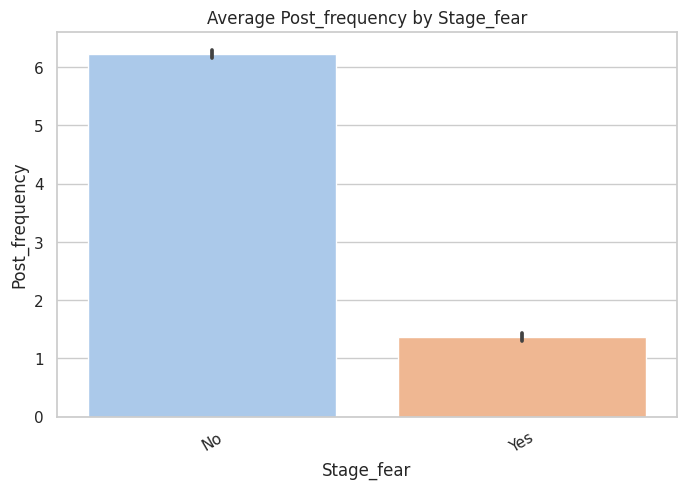

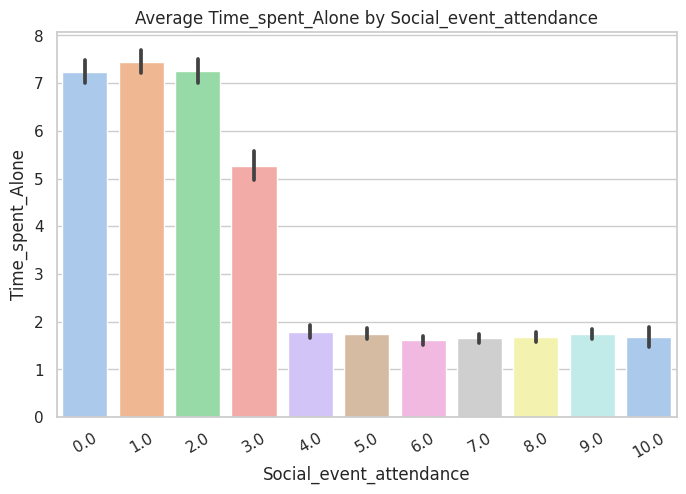

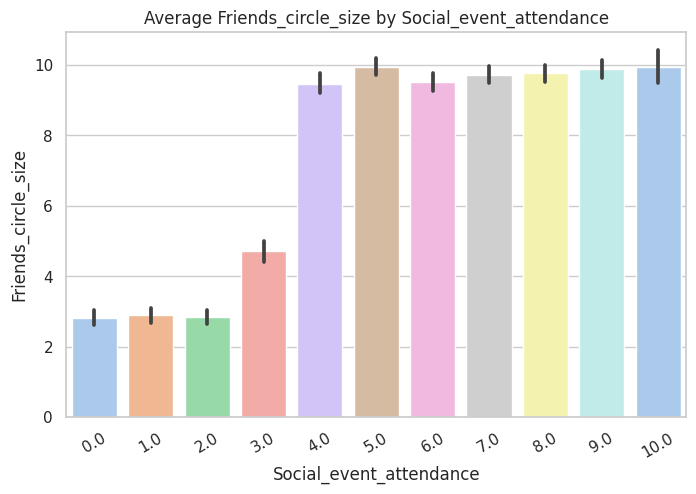

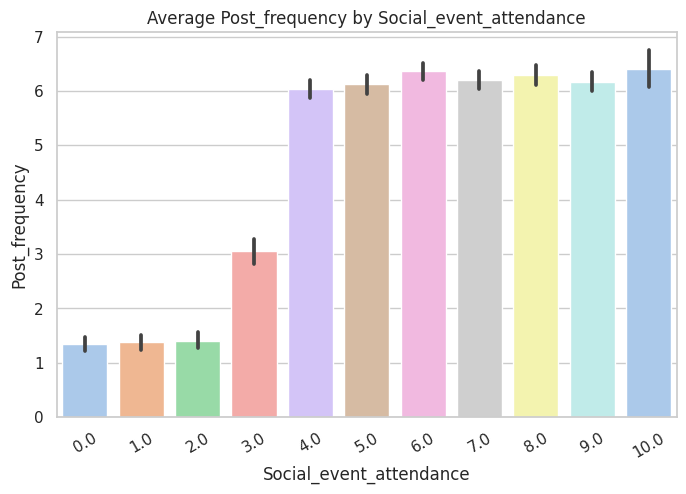

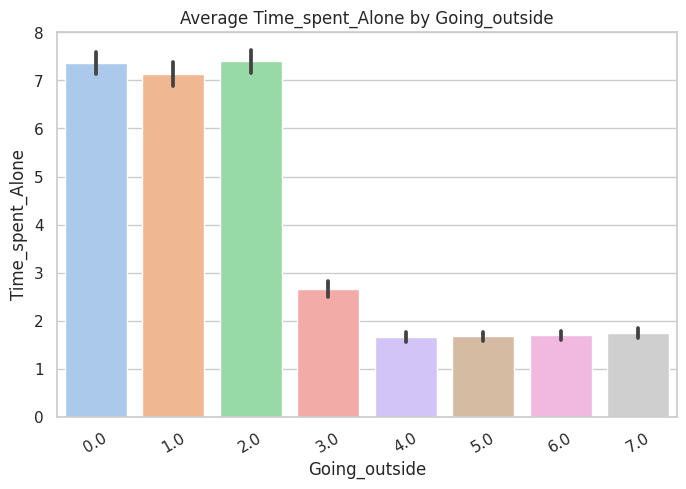

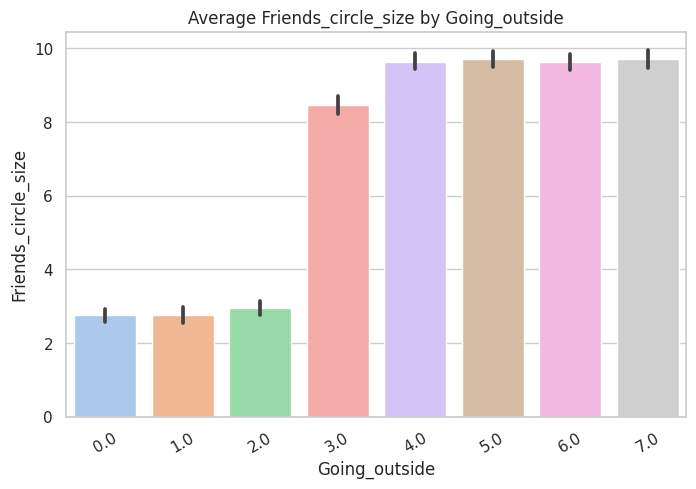

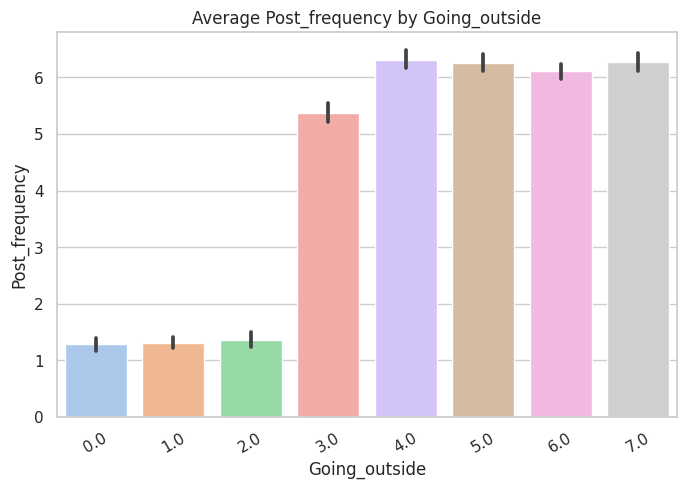

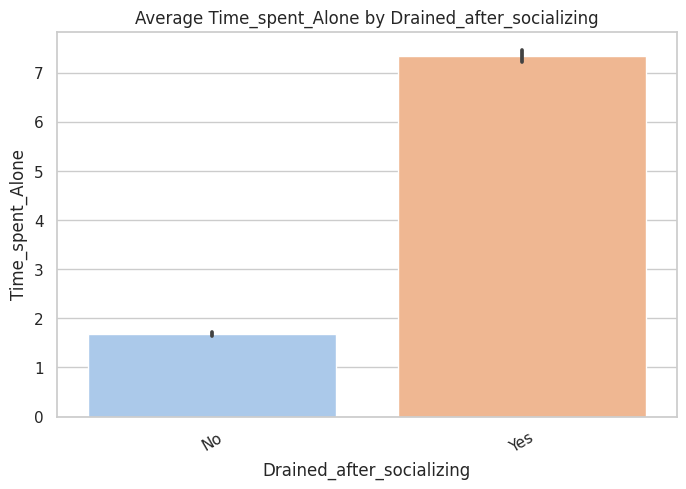

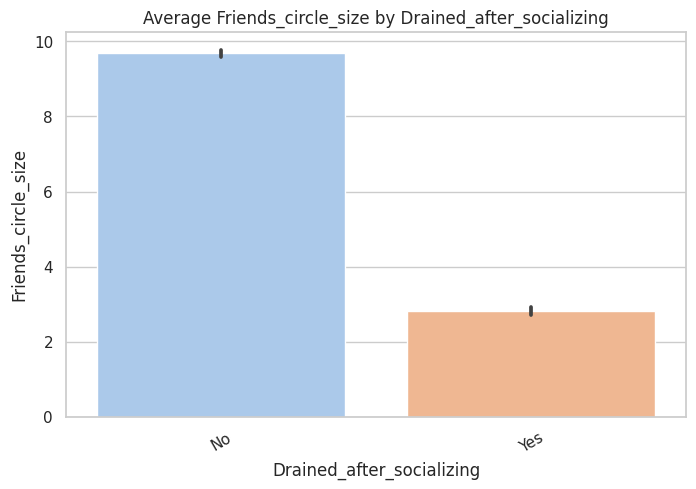

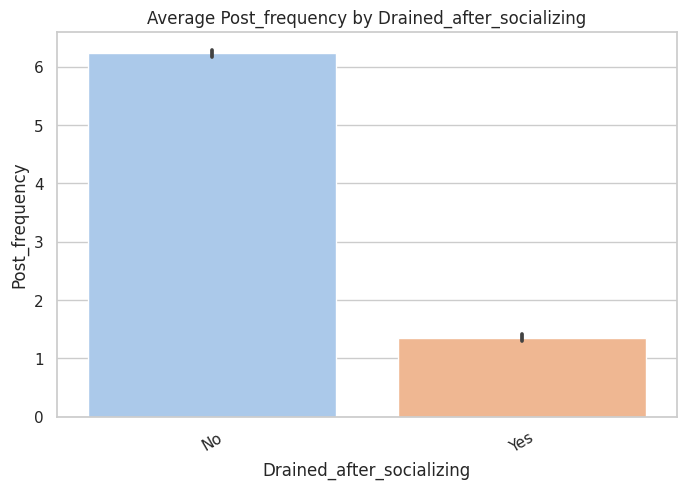

In [33]:
for cat in cat_cols:
    for num in num_cols:
        plt.figure()
        sns.barplot(data=test, x=cat, y=num, estimator="mean", palette="pastel")
        plt.title(f"Average {num} by {cat}")
        plt.xticks(rotation=30)
        plt.show()

## Data Preprocessing

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [35]:
train = train.drop(columns=['id'])
test_IDs = test['id']  # Keep for submission later
test = test.drop(columns=['id'])

y_train = train['Personality']
X_train = train.drop(columns=['Personality'])

In [36]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [37]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
test[num_cols] = num_imputer.transform(test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
test[cat_cols] = cat_imputer.transform(test[cat_cols])

In [38]:
# Encoding (binary Yes/No to 1/0)
le = LabelEncoder()
for col in cat_cols + ['Personality']:
    if col in X_train.columns:
        X_train[col] = le.fit_transform(X_train[col])
        test[col] = le.transform(test[col])
    elif col == 'Personality':
        y_train = le.fit_transform(y_train)

In [39]:
print("Training data shape:", X_train.shape)
print("Test data shape:", test.shape)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Target distribution:", np.bincount(y_train))

Training data shape: (18524, 7)
Test data shape: (6175, 7)
Numerical columns: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
Categorical columns: ['Stage_fear', 'Drained_after_socializing']
Target distribution: [13699  4825]


## ML Algorithms 

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

In [41]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [42]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(kernel="rbf", class_weight="balanced", random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        random_state=42,
        use_label_encoder=False,
        eval_metric="mlogloss",
        n_jobs=-1
    )
}

results = []


In [43]:
for name, model in models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    bal_acc = balanced_accuracy_score(y_val, y_pred) * 100  # %
    macro_f1 = f1_score(y_val, y_pred, average="macro") * 100  # %

    results.append([name, bal_acc, macro_f1])

    print("="*60)
    print(f"Model: {name}")
    print(f"Balanced Accuracy: {bal_acc:.2f}%")
    print(f"Macro F1-score:   {macro_f1:.2f}%")
    print("\nClassification Report:\n", classification_report(y_val, y_pred))

Model: Logistic Regression
Balanced Accuracy: 96.44%
Macro F1-score:   96.33%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2740
           1       0.94      0.95      0.95       965

    accuracy                           0.97      3705
   macro avg       0.96      0.96      0.96      3705
weighted avg       0.97      0.97      0.97      3705

Model: Decision Tree
Balanced Accuracy: 91.71%
Macro F1-score:   91.21%

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95      2740
           1       0.86      0.89      0.87       965

    accuracy                           0.93      3705
   macro avg       0.91      0.92      0.91      3705
weighted avg       0.93      0.93      0.93      3705

Model: Random Forest
Balanced Accuracy: 95.96%
Macro F1-score:   95.46%

Classification Report:
               precision    recall  f1-score   sup

In [44]:
results_df = pd.DataFrame(results, columns=["Model", "Balanced Accuracy (%)", "Macro F1 (%)"])
print("\nSummary of Results:\n", results_df)


Summary of Results:
                  Model  Balanced Accuracy (%)  Macro F1 (%)
0  Logistic Regression              96.439242     96.330369
1        Decision Tree              91.706346     91.207340
2        Random Forest              95.964790     95.460774
3    Gradient Boosting              96.402746     96.262962
4                  KNN              96.402746     96.262962
5                  SVM              96.436311     96.265448
6          Naive Bayes              96.384498     96.229292
7              XGBoost              96.003555     95.941867


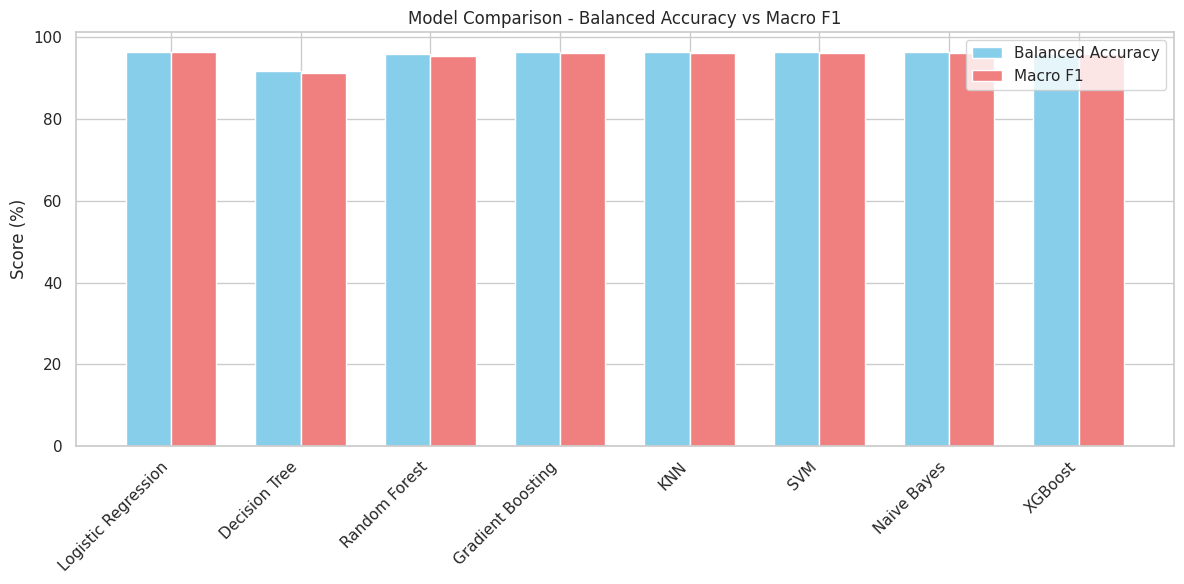

In [45]:
x = np.arange(len(results_df["Model"]))  # positions
width = 0.35 

plt.figure(figsize=(12,6))
plt.bar(x - width/2, results_df["Balanced Accuracy (%)"], width, label="Balanced Accuracy", color="skyblue")
plt.bar(x + width/2, results_df["Macro F1 (%)"], width, label="Macro F1", color="lightcoral")

plt.xticks(x, results_df["Model"], rotation=45, ha="right")
plt.ylabel("Score (%)")
plt.title("Model Comparison - Balanced Accuracy vs Macro F1")
plt.legend()
plt.tight_layout()
plt.show()

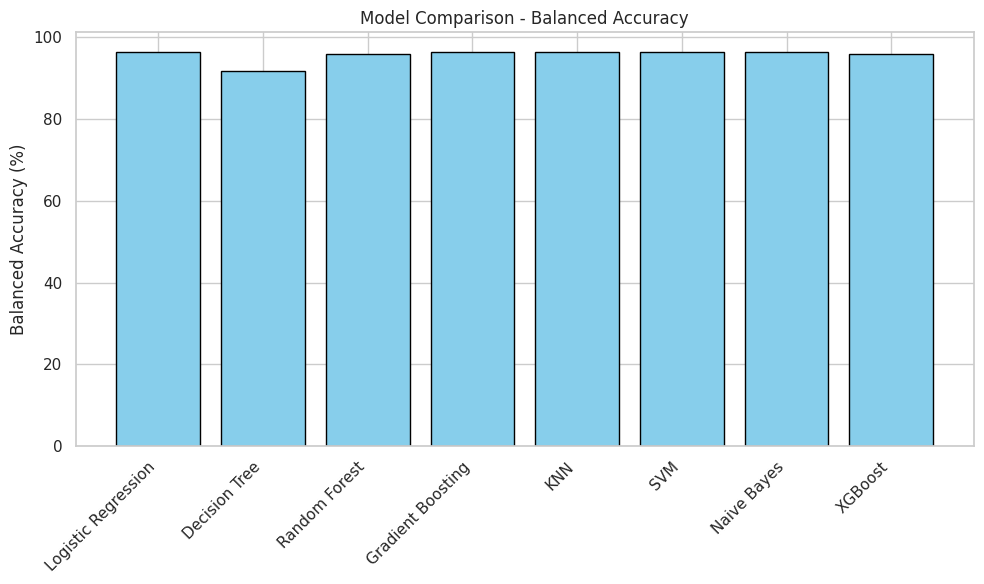

In [46]:
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["Balanced Accuracy (%)"], color="skyblue", edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Balanced Accuracy (%)")
plt.title("Model Comparison - Balanced Accuracy")
plt.tight_layout()
plt.show()

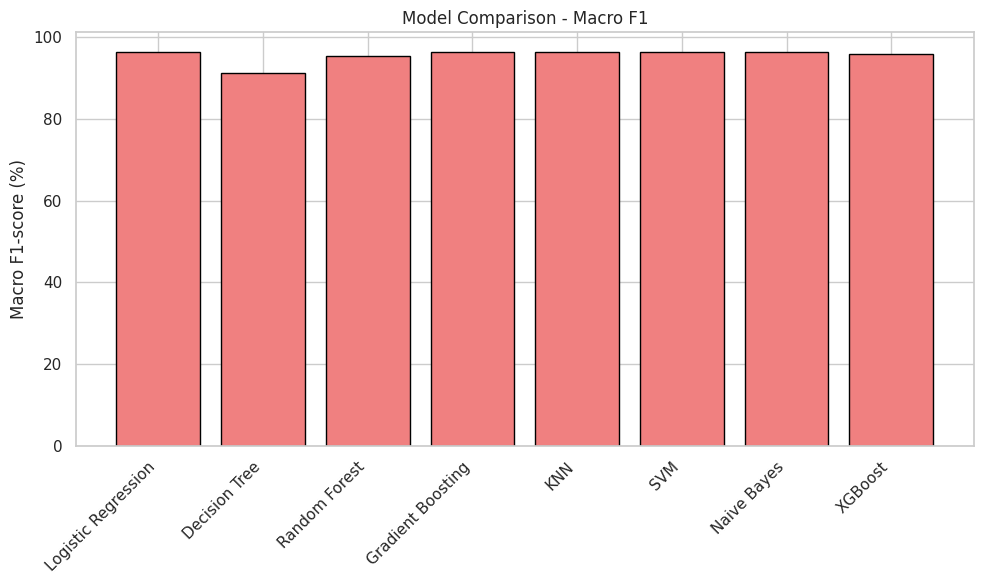

In [47]:
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["Macro F1 (%)"], color="lightcoral", edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro F1-score (%)")
plt.title("Model Comparison - Macro F1")
plt.tight_layout()
plt.show()


In [48]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [49]:
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
lgbm_model.fit(X_tr, y_tr)
y_pred_lgbm = lgbm_model.predict(X_val)


[LightGBM] [Info] Number of positive: 3860, number of negative: 10959
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 62
[LightGBM] [Info] Number of data points in the train set: 14819, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


In [50]:
lgbm_bal_acc = balanced_accuracy_score(y_val, y_pred_lgbm)
lgbm_macro_f1 = f1_score(y_val, y_pred_lgbm, average='macro')

In [51]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    scale_pos_weight=(len(y_tr) - sum(y_tr)) / sum(y_tr),  # class balance
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_tr, y_tr)
y_pred_xgb = xgb_model.predict(X_val)

xgb_bal_acc = balanced_accuracy_score(y_val, y_pred_xgb)
xgb_macro_f1 = f1_score(y_val, y_pred_xgb, average='macro')


In [52]:
results_df = pd.DataFrame({
    'Model': ['RandomForest', 'LightGBM', 'XGBoost'],
    'Balanced Accuracy': [bal_acc, lgbm_bal_acc, xgb_bal_acc],
    'Macro F1': [macro_f1, lgbm_macro_f1, xgb_macro_f1]
})

print(results_df)

          Model  Balanced Accuracy   Macro F1
0  RandomForest          96.003555  95.941867
1      LightGBM           0.962568   0.959942
2       XGBoost           0.963144   0.961595


In [53]:
final_xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)
final_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [54]:
test_preds = final_xgb.predict(test)

In [55]:
submission = pd.DataFrame({
    'id': test_IDs,
    'Personality': test_preds
})
submission['Personality'] = submission['Personality'].map({0: 'Extrovert', 1: 'Introvert'})

submission_path = "final_xgb_submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")

Submission saved to final_xgb_submission.csv


In [56]:
val_preds = final_xgb.predict(X_val)

In [57]:
bal_acc = balanced_accuracy_score(y_val, val_preds)
macro_f1 = f1_score(y_val, val_preds, average='macro')

In [58]:
print(f"Balanced Accuracy: {bal_acc:.4f}")

Balanced Accuracy: 0.9677


In [59]:
print(f"Macro F1-score: {macro_f1:.4f}")

Macro F1-score: 0.9658


In [60]:
print("\nClassification Report:")
print(classification_report(y_val, val_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2740
           1       0.94      0.96      0.95       965

    accuracy                           0.97      3705
   macro avg       0.96      0.97      0.97      3705
weighted avg       0.97      0.97      0.97      3705



## Thank you....pls upvote!!!!!!